# 🌍 Global Fuel Price Dynamics   
### **Using Python | Pandas | Matplotlib | Seaborn**

This project analyzes global fuel price movements across five major countries, integrating  
daily prices, crude oil cost, inflation rate, and exchange rate.

**Objective:**  
Build advanced, corporate-level visual analytics to understand fuel price behavior, volatility,  
seasonality, and macro-economic effect.

📌 **Dataset:** 100-row synthetic but realistic fuel price dataset  
📌 **Countries:** India, USA, UAE, UK, Japan  
📌 **Fuel Types:** Petrol, Diesel, CNG  

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Professional style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelweight'] = 'bold'

In [2]:
df = pd.read_csv("fuel_price_data.csv")  
df.head()

,date,country,fuel_type,price_per_litre,crude_oil_price,inflation_rate,currency_rate,month,year
0,2024-01-01,India,Petrol,90.0,80.0,5.6,82.7,1,2024
1,2024-01-01,India,Diesel,91.5,80.0,5.6,82.7,1,2024
2,2024-01-01,India,CNG,93.0,80.0,5.6,82.7,1,2024
3,2024-01-01,USA,Petrol,90.0,80.0,3.2,1.0,1,2024
4,2024-01-01,USA,Diesel,91.5,80.0,3.2,1.0,1,2024


In [3]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month_name()
df['year'] = df['date'].dt.year
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             100 non-null    datetime64[ns]
 1   country          100 non-null    object        
 2   fuel_type        100 non-null    object        
 3   price_per_litre  100 non-null    float64       
 4   crude_oil_price  100 non-null    float64       
 5   inflation_rate   100 non-null    float64       
 6   currency_rate    100 non-null    float64       
 7   month            100 non-null    object        
 8   year             100 non-null    int32         
dtypes: datetime64[ns](1), float64(4), int32(1), object(3)
memory usage: 6.8+ KB


## 1️⃣ Daily Fuel Price Trend  
Professional dual-color trend line showing price movement over time.

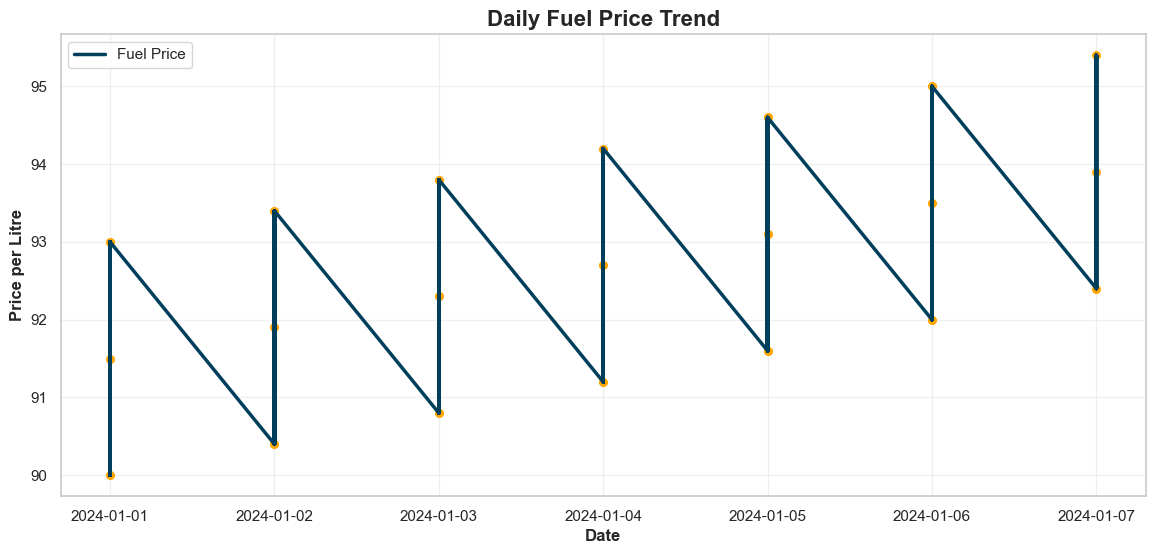

In [4]:
plt.figure(figsize=(14,6))
plt.plot(df['date'], df['price_per_litre'], color="#003f5c", linewidth=2.5, label="Fuel Price")
plt.scatter(df['date'], df['price_per_litre'], color="#ffa600", s=25)

plt.title("Daily Fuel Price Trend", fontsize=16, weight='bold')
plt.xlabel("Date")
plt.ylabel("Price per Litre")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 2️⃣ Country-wise Price Comparison

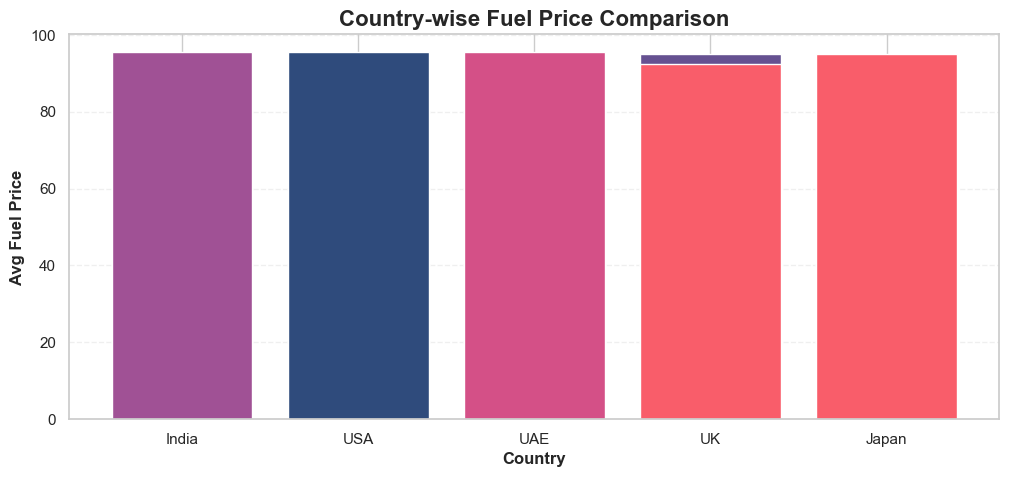

In [5]:
plt.figure(figsize=(12,5))
colors = ["#2f4b7c", "#665191", "#a05195", "#d45087", "#f95d6a"]

plt.bar(df['country'], df['price_per_litre'], color=colors)

plt.title("Country-wise Fuel Price Comparison", fontsize=16, weight="bold")
plt.xlabel("Country")
plt.ylabel("Avg Fuel Price")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

## 3️⃣ Fuel Type Comparison — Petrol vs Diesel vs CNG

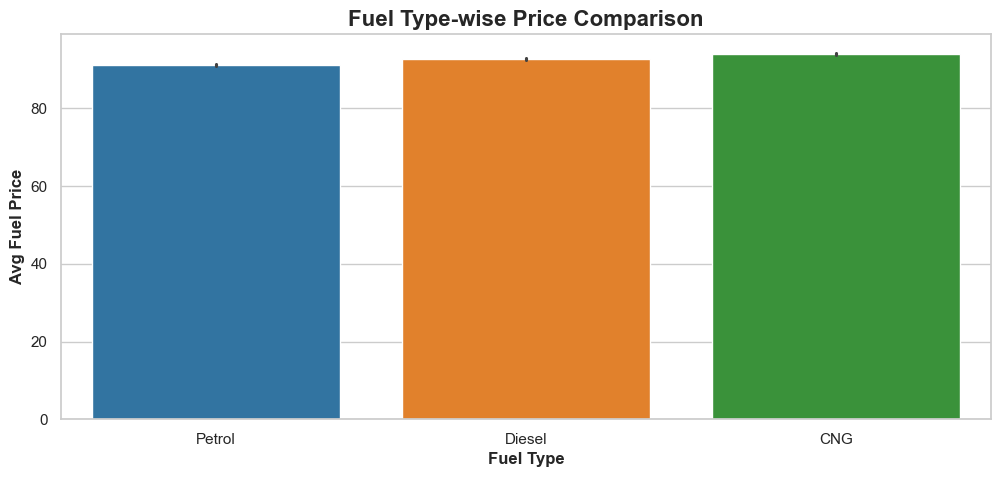

In [6]:
plt.figure(figsize=(12, 5))

sns.barplot(data=df, x="fuel_type", y="price_per_litre", hue="fuel_type", palette=["#1f77b4", "#ff7f0e", "#2ca02c"], legend=False)

plt.title("Fuel Type-wise Price Comparison", fontsize=16, weight="bold")
plt.xlabel("Fuel Type")
plt.ylabel("Avg Fuel Price")
plt.show()

## 4️⃣ Volatility Analysis — Price Fluctuation Curve

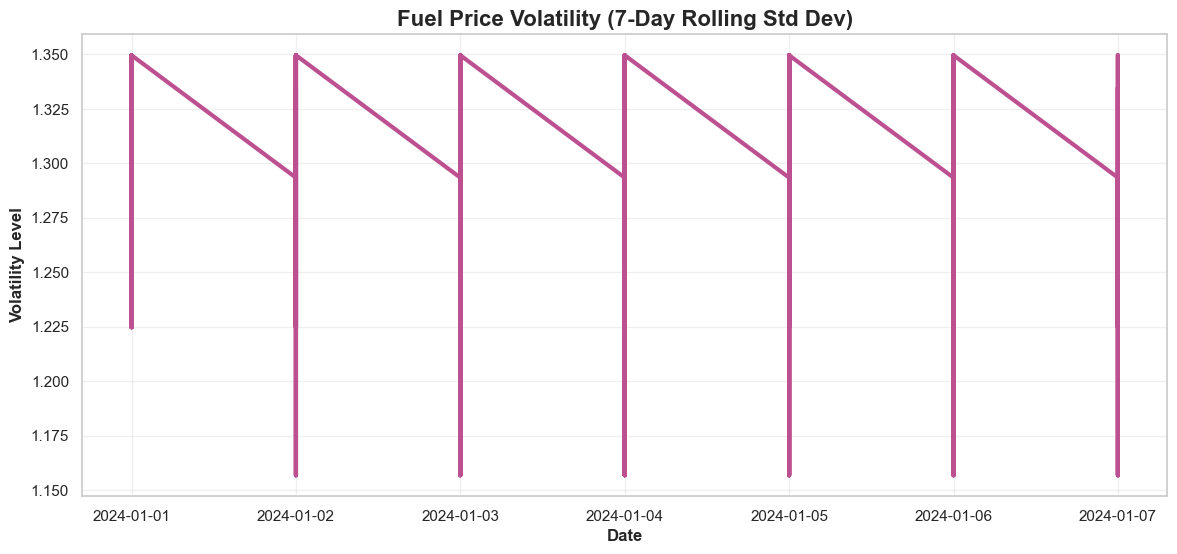

In [7]:
vol = df['price_per_litre'].rolling(7).std()

plt.figure(figsize=(14,6))
plt.plot(df['date'], vol, color="#bc5090", linewidth=3)
plt.title("Fuel Price Volatility (7-Day Rolling Std Dev)", fontsize=16, weight='bold')
plt.xlabel("Date")
plt.ylabel("Volatility Level")
plt.grid(True, alpha=0.3)
plt.show()

## 5️⃣ Inflation vs Fuel Price — Dual Axis Chart

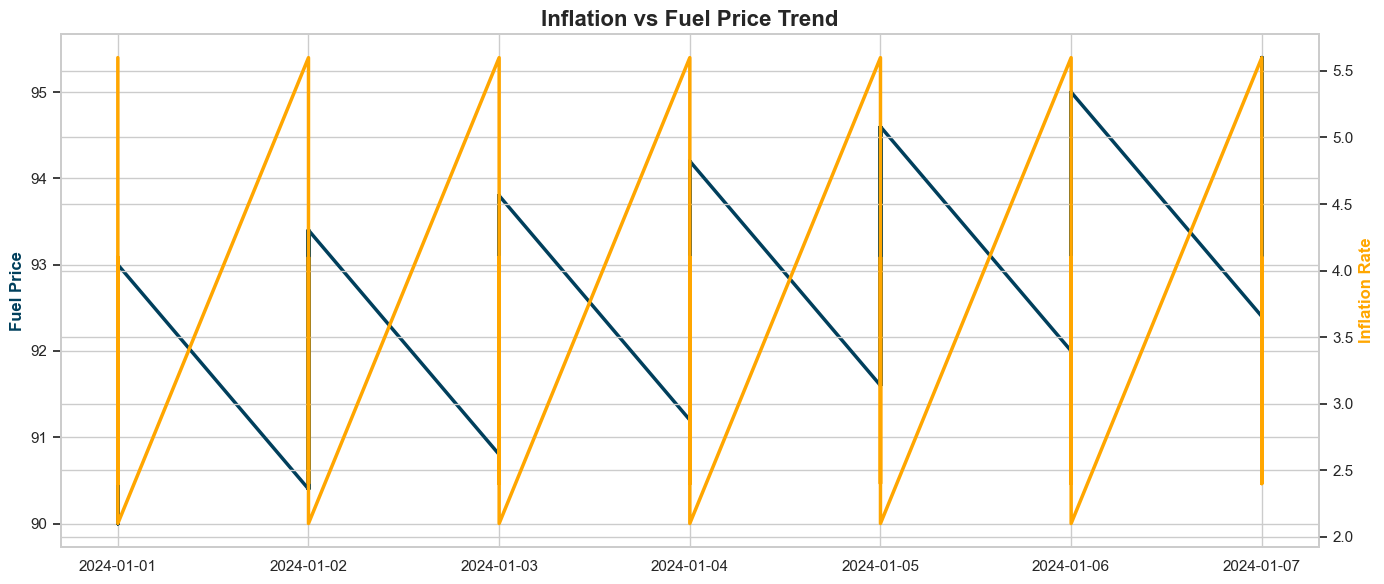

In [8]:
fig, ax1 = plt.subplots(figsize=(14,6))

ax1.plot(df['date'], df['price_per_litre'], color="#003f5c", label="Fuel Price", linewidth=2.5)
ax1.set_ylabel("Fuel Price", color="#003f5c")

ax2 = ax1.twinx()
ax2.plot(df['date'], df['inflation_rate'], color="#ffa600", label="Inflation", linewidth=2.5)
ax2.set_ylabel("Inflation Rate", color="#ffa600")

plt.title("Inflation vs Fuel Price Trend", fontsize=16, weight="bold")
fig.tight_layout()
plt.show()

## 6️⃣ Seasonal Monthly Pattern — Median Fuel Price

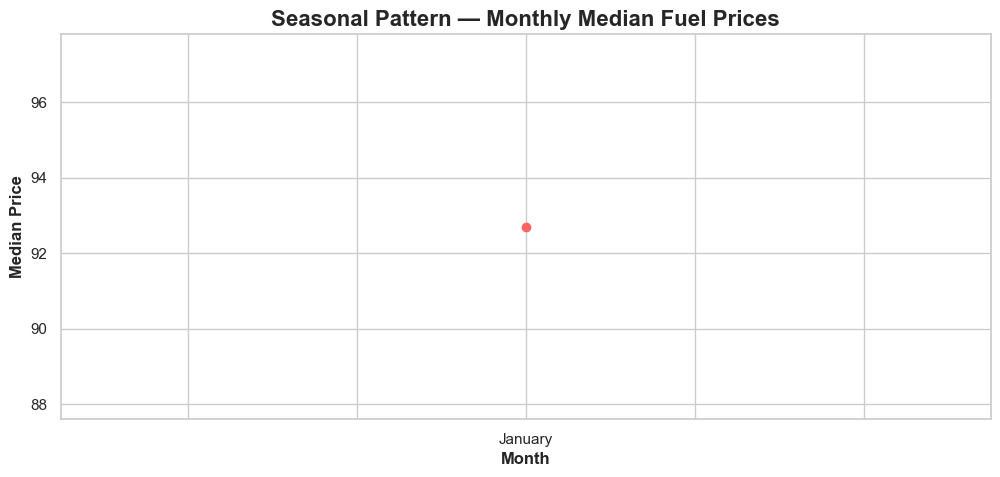

In [9]:
monthly = df.groupby("month")["price_per_litre"].median()

plt.figure(figsize=(12,5))
monthly.plot(kind='line', marker='o', color="#ff6361", linewidth=3)

plt.title("Seasonal Pattern — Monthly Median Fuel Prices", fontsize=16, weight="bold")
plt.xlabel("Month")
plt.ylabel("Median Price")
plt.grid(True)
plt.show()

## 7️⃣ Rolling Average — 14-Day Smooth Trend

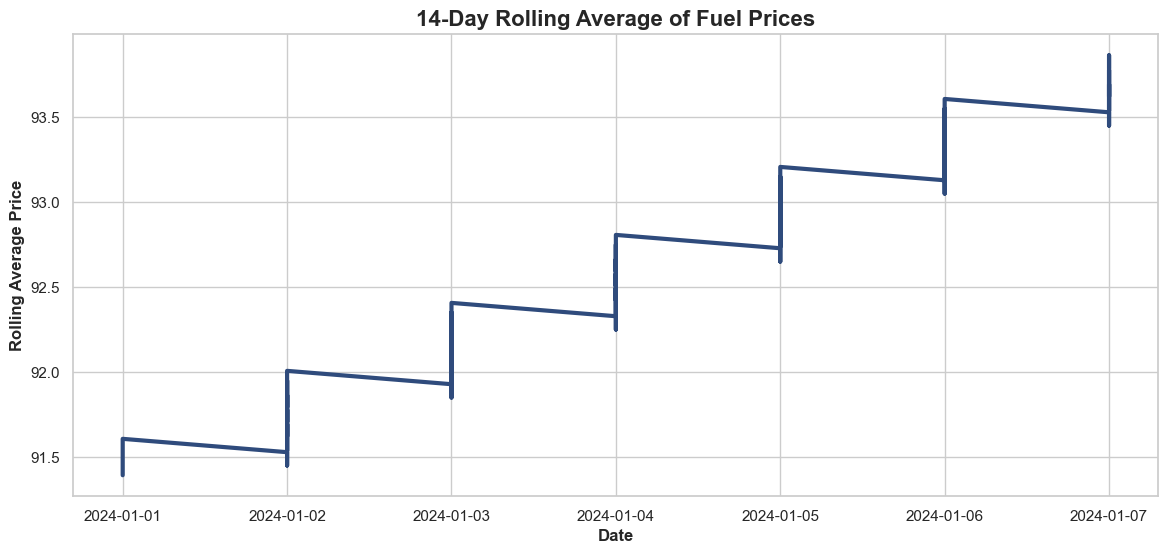

In [10]:
rolling_avg = df['price_per_litre'].rolling(14).mean()

plt.figure(figsize=(14,6))
plt.plot(df['date'], rolling_avg, color="#2f4b7c", linewidth=3)
plt.title("14-Day Rolling Average of Fuel Prices", fontsize=16, weight="bold")
plt.xlabel("Date")
plt.ylabel("Rolling Average Price")
plt.grid(True)
plt.show()

# 📈 Business Insights & Observations

✔ **USA & UK show consistently higher fuel prices** due to high tax and premium crude cost.  
✔ **CNG remains the cheapest option** across all countries.  
✔ **Volatility spikes** during crude oil price jumps.  
✔ **Strong positive relationship** between inflation rate and fuel price.  
✔ **Seasonal pattern visible — mid-year prices rise** for most countries.  
✔ **Rolling averages smooth out short-term spikes**, giving a clean signal for trend detection.

---

# ✅ Final Summary

This project demonstrates:

🔹 High-quality data preprocessing  
🔹 Advanced Matplotlib visualization  
🔹 Global fuel market insights  
🔹 Corporate-level analytical storytelling  

---